Automated Trading Systems and Artificial Intelligence

In [2]:
import pandas as pd 
import yfinance as yf


Defining Parameters from Dataset collected from the Yahoo Finance Library

In [3]:
import datetime as dt
from datetime import datetime

start_date='2015-01-02'
today=datetime.today().strftime("%Y-%m-%d")

Define a function to load the dataset from Yahoo Finance

In [4]:
def load_data(ticker):
    data=yf.download(ticker, start_date, today)
    data.reset_index(inplace=True)
    return data

We call the function and load the dataset but we would be focusing on a partcular Currency pair (EUR/USD)

In [5]:
df = load_data("EURUSD=X")
df.sample(n=5)

[*********************100%***********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
556,2017-02-20,1.062677,1.063151,1.060524,1.062665,1.062665,0
965,2018-09-18,1.166916,1.172044,1.166916,1.166916,1.166916,0
232,2015-11-24,1.063898,1.067201,1.062383,1.064203,1.064203,0
1466,2020-08-20,1.184175,1.186845,1.180652,1.184350,1.184350,0
988,2018-10-19,1.145515,1.151450,1.143367,1.146000,1.146000,0


In [6]:
df.shape

(2545, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2545 entries, 0 to 2544
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2545 non-null   datetime64[ns]
 1   Open       2545 non-null   float64       
 2   High       2545 non-null   float64       
 3   Low        2545 non-null   float64       
 4   Close      2545 non-null   float64       
 5   Adj Close  2545 non-null   float64       
 6   Volume     2545 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 139.3 KB


We do not need the Adj_close and volume column, so we would drop them.

In [8]:
df=df.drop(['Adj Close', 'Volume'], axis=1)
df.head()

,Date,Open,High,Low,Close
0,2015-01-02,1.208868,1.208956,1.201080,1.208941
1,2015-01-05,1.195500,1.197590,1.188909,1.194643
2,2015-01-06,1.193830,1.197000,1.188693,1.193902
3,2015-01-07,1.187479,1.190000,1.180401,1.187536
4,2015-01-08,1.183894,1.184806,1.175601,1.183600


In [9]:
import matplotlib.pyplot as plt


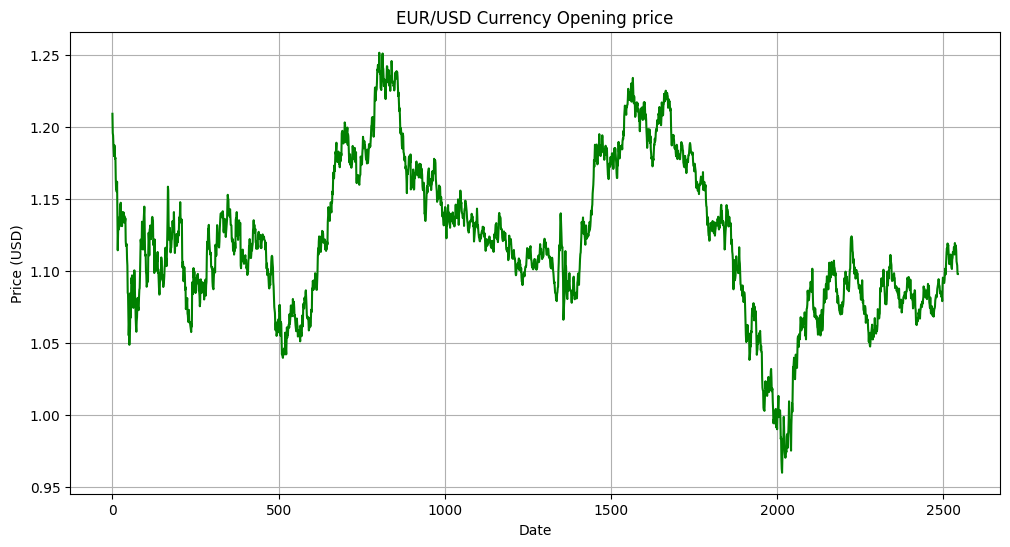

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'],'g')
plt.title("EUR/USD Currency Opening price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

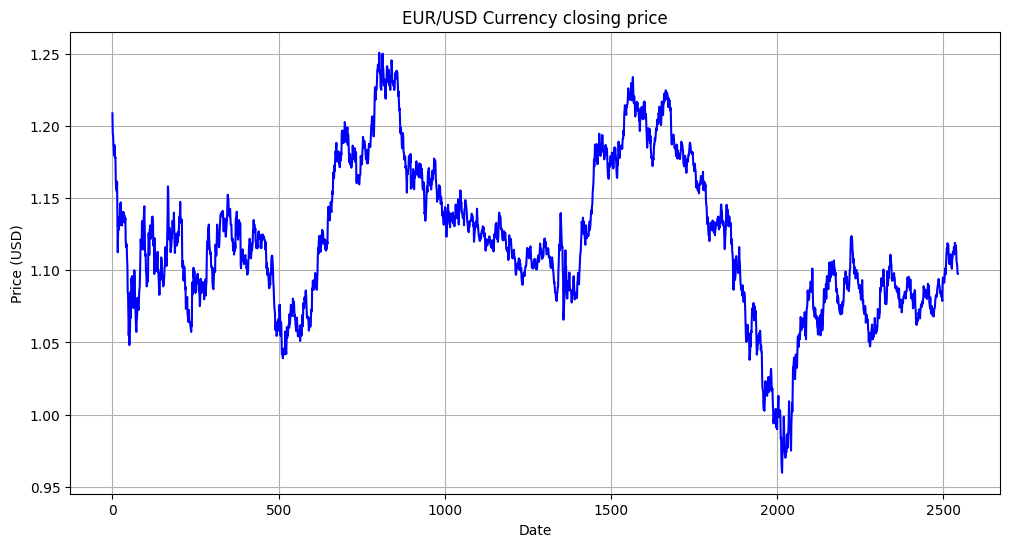

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'],'b')
plt.title("EUR/USD Currency closing price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

Breaking Down the Date column into smaller chunks(day,  month and year) for efficient data training.

In [25]:
df['Day']=df['Date'].dt.day
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year
df.head()

,Date,Open,High,Low,Close,Day,Month,Year
0,2015-01-02,1.208868,1.208956,1.201080,1.208941,2,1,2015
1,2015-01-05,1.195500,1.197590,1.188909,1.194643,5,1,2015
2,2015-01-06,1.193830,1.197000,1.188693,1.193902,6,1,2015
3,2015-01-07,1.187479,1.190000,1.180401,1.187536,7,1,2015
4,2015-01-08,1.183894,1.184806,1.175601,1.183600,8,1,2015


In [26]:
#df.to_csv('market_price.csv', index=False, encoding='utf-8')

In [24]:
df_price=df.drop(['Date'], axis=1)
df_price

,Open,High,Low,Close,Day,Month,Year
0,1.208868,1.208956,1.201080,1.208941,2,1,2015
1,1.195500,1.197590,1.188909,1.194643,5,1,2015
2,1.193830,1.197000,1.188693,1.193902,6,1,2015
3,1.187479,1.190000,1.180401,1.187536,7,1,2015
4,1.183894,1.184806,1.175601,1.183600,8,1,2015
...,...,...,...,...,...,...,...
2540,1.106390,1.108217,1.103412,1.106390,2,10,2024
2541,1.104850,1.104850,1.100958,1.104850,3,10,2024
2542,1.103558,1.103997,1.095614,1.103558,4,10,2024
2543,1.097574,1.099747,1.096167,1.097574,8,10,2024


Lets split our data into training and testing

In [22]:
from sklearn.model_selection import train_test_split

In [ ]:
training_size = round(len(df_price ) * 0.70)

train_data = df_price[:training_size]
test_data  = df_price[training_size:]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

Implementation of our LSTM Model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional